## Imports

In [4]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import os
import sys
import matplotlib.pyplot as plt

os.chdir("/home/patrick/ansermodelling")

from models.FFNN_network import FFNN
from data.anser_dataset import AnserDataset
from models.train import train


## Dataset

In [5]:
dataset = AnserDataset("data/dataset.npz")

### Spatial Distribution

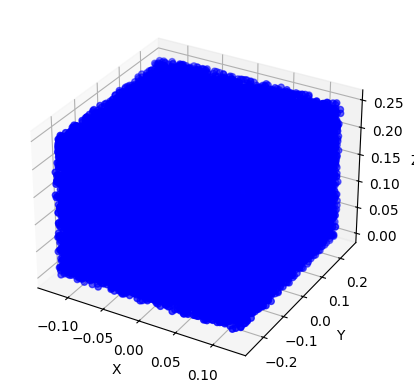

In [6]:
positions = dataset.y[:,:3]

# Create a new figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create a scatter plot
ax.scatter(positions[:,0], positions[:,1], positions[:,2], c='blue', marker='o')

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Show the plot
plt.show()

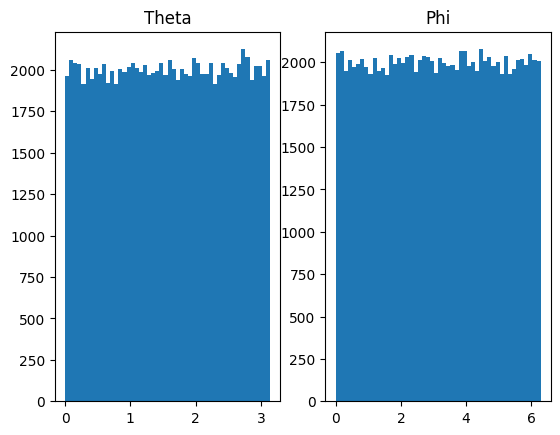

In [7]:
theta = dataset.y[:, 3]
phi = dataset.y[:, 4]

fig, axes = plt.subplots(1, 2)
axes[0].hist(theta, bins=50)
axes[0].set_title("Theta")
axes[1].hist(phi, bins=50)
axes[1].set_title("Phi")
plt.show()

Distrubtion of Fluxes

-0.0054432433
17.87918


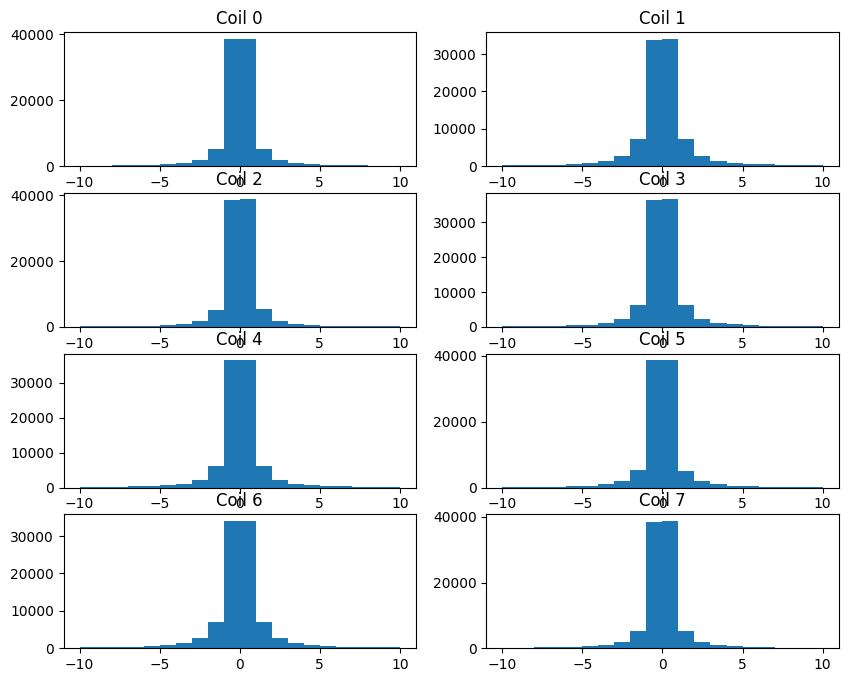

In [8]:
fluxes = dataset.x.numpy()
fig, axes = plt.subplots(4, 2, figsize=(10, 8))

print(np.mean(fluxes))
print(np.std(fluxes))

for ax, i in zip(axes.flat, range(8)):
    ax.hist(fluxes[:, i], bins=20,range=(-10, 10))
    ax.set_title(f"Coil {i}")
plt.show()

In [9]:
from torch.utils.data import random_split
n = len(dataset)
n_train = int(0.8 * n)
n_test = n - n_train

train_set, test_set = random_split(dataset, [n_train, n_test])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [10]:
model = FFNN(input_dim=8, output_dim=5, hidden_dims=[64,256,64])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [11]:
train_losses, test_losses = train(model, train_loader, test_loader, optimizer, epochs=200, print_losses = True)

epoch 	 Training Loss 	 Test Loss 	 Mean pos error train 	 Mean Pos Error Test
1 	 0.6609 	  0.5025 	 0.1249 	 0.1023
2 	 0.4535 	  0.4184 	 0.0989 	 0.0946
3 	 0.3993 	  0.3839 	 0.0947 	 0.0946
4 	 0.3687 	  0.3679 	 0.0937 	 0.0957
5 	 0.3505 	  0.3485 	 0.0932 	 0.0933
6 	 0.3376 	  0.3540 	 0.0940 	 0.0939
7 	 0.3255 	  0.3265 	 0.0944 	 0.0969
8 	 0.3176 	  0.3454 	 0.0954 	 0.0966
9 	 0.3090 	  0.3210 	 0.0943 	 0.0955
10 	 0.3033 	  0.3108 	 0.0943 	 0.0975
11 	 0.2945 	  0.2990 	 0.0936 	 0.0920
12 	 0.2921 	  0.2995 	 0.0918 	 0.0947
13 	 0.2867 	  0.3015 	 0.0916 	 0.0924
14 	 0.2817 	  0.3080 	 0.0916 	 0.0920
15 	 0.2778 	  0.2939 	 0.0914 	 0.0919
16 	 0.2745 	  0.2891 	 0.0909 	 0.0912
17 	 0.2715 	  0.2845 	 0.0900 	 0.0894
18 	 0.2674 	  0.2811 	 0.0898 	 0.0913
19 	 0.2647 	  0.2889 	 0.0902 	 0.0889
20 	 0.2608 	  0.2898 	 0.0903 	 0.0925
21 	 0.2592 	  0.2775 	 0.0901 	 0.0888
22 	 0.2553 	  0.2826 	 0.0898 	 0.0910
23 	 0.2524 	  0.2756 	 0.0897 	 0.0922
24 	 0.252

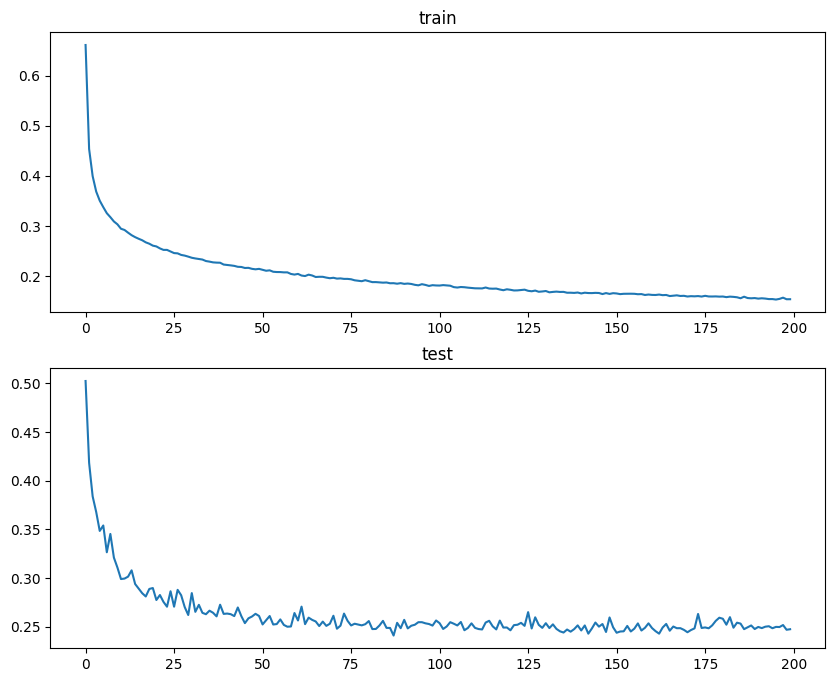

In [13]:
fig, axes = plt.subplots(2,figsize=(10, 8))
axes[0].plot(train_losses)
axes[0].set_title("train")
axes[1].plot(test_losses)
axes[1].set_title("test")
plt.show()


Looks like I might be overfitting. I think I might normalise the data 